# AI/ML Model for Malaria Risk Prediction

This notebook builds a standalone supervised machine learning model using the cleaned malaria data extracted from the PDFs.

## Objective

Predict whether a state will become **high malaria risk in the next year**.

This is separate from the mechanistic SIR/SEIR and ARIMA modelling notebook. It focuses on a classic AI/ML workflow:

1. Load and prepare data
2. Engineer lag and rolling features
3. Define a risk target
4. Train ML models
5. Evaluate performance
6. Interpret feature importance
7. Generate predictions for selected regions

## 0. Setup

Run the install cell once if packages are missing.

In [1]:
# Uncomment and run this cell if packages are missing.
# %pip install pandas numpy matplotlib scikit-learn

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
DISTRICT_CSV = DATA_DIR / "processed" / "district_malaria_2000_2024_from_pdf.csv"
POPULATION_CSV = DATA_DIR / "raw" / "state_population_2011.csv"

SELECTED_REGIONS = ["Odisha", "Mizoram", "Tripura"]

## 1. Load Data

The district CSV is aggregated to state-year level because the ML target is next-year regional malaria risk.

In [3]:
district = pd.read_csv(DISTRICT_CSV)
population = pd.read_csv(POPULATION_CSV)

district["year"] = district["year"].astype(int)
district["total_cases"] = pd.to_numeric(district["total_cases"], errors="coerce")
district["total_deaths"] = pd.to_numeric(district["total_deaths"], errors="coerce")

state_year = (
    district
    .groupby(["year", "state"], as_index=False)
    .agg(
        total_cases=("total_cases", "sum"),
        total_deaths=("total_deaths", "sum"),
        district_count=("district", "nunique"),
    )
    .merge(population[["state", "population_2011"]], on="state", how="left")
)

state_year["cases_per_100k"] = state_year["total_cases"] / state_year["population_2011"] * 100_000
state_year["deaths_per_100k"] = state_year["total_deaths"] / state_year["population_2011"] * 100_000
state_year = state_year.dropna(subset=["population_2011"]).sort_values(["state", "year"])

display(state_year.head())
print("Rows:", len(state_year))
print("States/UTs:", state_year["state"].nunique())
print("Years:", state_year["year"].min(), "-", state_year["year"].max())

,year,state,total_cases,total_deaths,district_count,population_2011,cases_per_100k,deaths_per_100k
0,2000,Andaman And Nicobar Islands,1990,5,4,380581,522.884747,1.313781
35,2001,Andaman And Nicobar Islands,434,0,1,380581,114.036171,0.000000
70,2002,Andaman And Nicobar Islands,1557,4,4,380581,409.111332,1.051025
105,2003,Andaman And Nicobar Islands,427,0,1,380581,112.196878,0.000000
140,2004,Andaman And Nicobar Islands,1800,4,4,380581,472.961078,1.051025


Rows: 858
States/UTs: 38
Years: 2000 - 2024


## 2. Exploratory View

Before modelling, inspect the selected high-burden regions.

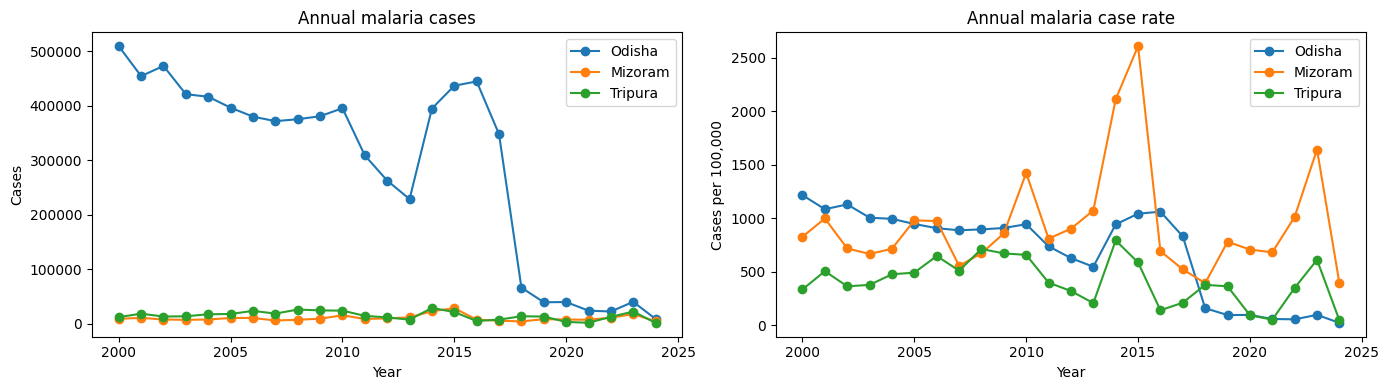

In [4]:
selected = state_year[state_year["state"].isin(SELECTED_REGIONS)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for region in SELECTED_REGIONS:
    region_df = selected[selected["state"] == region]
    axes[0].plot(region_df["year"], region_df["total_cases"], marker="o", label=region)
    axes[1].plot(region_df["year"], region_df["cases_per_100k"], marker="o", label=region)

axes[0].set_title("Annual malaria cases")
axes[0].set_ylabel("Cases")
axes[0].set_xlabel("Year")
axes[0].legend()

axes[1].set_title("Annual malaria case rate")
axes[1].set_ylabel("Cases per 100,000")
axes[1].set_xlabel("Year")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Feature Engineering

We use only information that would be available before the prediction year.

Features include:

- lagged cases
- lagged case rates
- lagged deaths
- rolling averages
- year-over-year percentage change
- population and district count

Target:

- `high_risk_next_year = 1` if the next year's case rate is in the top 25% of state-year observations.

In [5]:
ml_df = state_year.copy().sort_values(["state", "year"])

group = ml_df.groupby("state")

for col in ["total_cases", "total_deaths", "cases_per_100k", "deaths_per_100k"]:
    ml_df[f"{col}_lag1"] = group[col].shift(1)
    ml_df[f"{col}_lag2"] = group[col].shift(2)
    ml_df[f"{col}_lag3"] = group[col].shift(3)

ml_df["cases_rate_roll3"] = group["cases_per_100k"].transform(lambda s: s.shift(1).rolling(3).mean())
ml_df["cases_rate_roll5"] = group["cases_per_100k"].transform(lambda s: s.shift(1).rolling(5).mean())
ml_df["cases_yoy_change"] = group["total_cases"].pct_change().replace([np.inf, -np.inf], np.nan)
ml_df["rate_yoy_change"] = group["cases_per_100k"].pct_change().replace([np.inf, -np.inf], np.nan)

ml_df["next_year_cases"] = group["total_cases"].shift(-1)
ml_df["next_year_rate"] = group["cases_per_100k"].shift(-1)

risk_threshold = ml_df["next_year_rate"].quantile(0.75)
ml_df["high_risk_next_year"] = (ml_df["next_year_rate"] >= risk_threshold).astype(int)

feature_cols = [
    "year",
    "population_2011",
    "district_count",
    "total_cases_lag1",
    "total_cases_lag2",
    "total_cases_lag3",
    "total_deaths_lag1",
    "cases_per_100k_lag1",
    "cases_per_100k_lag2",
    "cases_per_100k_lag3",
    "deaths_per_100k_lag1",
    "cases_rate_roll3",
    "cases_rate_roll5",
    "cases_yoy_change",
    "rate_yoy_change",
]

model_df = ml_df.dropna(subset=feature_cols + ["next_year_rate", "high_risk_next_year"]).copy()

print("Risk threshold:", round(risk_threshold, 2), "cases per 100,000")
print("Model rows:", len(model_df))
display(model_df[["state", "year", "cases_per_100k", "next_year_rate", "high_risk_next_year"]].head())

Risk threshold: 189.19 cases per 100,000
Model rows: 626


,state,year,cases_per_100k,next_year_rate,high_risk_next_year
175,Andaman And Nicobar Islands,2005,849.753403,4957.157609,1
210,Andaman And Nicobar Islands,2006,4957.157609,7866.393751,1
278,Andaman And Nicobar Islands,2008,7866.393751,5801.918645,1
346,Andaman And Nicobar Islands,2010,5801.918645,4038.562093,1
414,Andaman And Nicobar Islands,2012,4038.562093,2352.981363,1


## 4. Train/Test Split

This is a time-aware split:

- Training: years up to 2019
- Testing: years after 2019

This avoids training on future years when predicting later years.

In [6]:
train = model_df[model_df["year"] <= 2019].copy()
test = model_df[model_df["year"] > 2019].copy()

X_train = train[feature_cols]
y_train = train["high_risk_next_year"]
X_test = test[feature_cols]
y_test = test["high_risk_next_year"]

print("Train rows:", len(train))
print("Test rows:", len(test))
print("Train high-risk rate:", round(y_train.mean(), 3))
print("Test high-risk rate:", round(y_test.mean(), 3))

Train rows: 502
Test rows: 124
Train high-risk rate: 0.265
Test high-risk rate: 0.065


## 5. Train Multiple AI/ML Models

Models:

- Dummy baseline
- Logistic Regression
- Random Forest
- Gradient Boosting

In [7]:
models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced",
        min_samples_leaf=3,
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, prob) if len(set(y_test)) > 1 else np.nan
    else:
        prob = pred
        auc = np.nan

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, pred, average="binary", zero_division=0
    )

    results.append({
        "model": name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": auc,
    })

results_df = pd.DataFrame(results).sort_values(["f1", "roc_auc"], ascending=False)
display(results_df)

,model,precision,recall,f1,roc_auc
2,Random Forest,0.857143,0.75,0.800000,0.984914
1,Logistic Regression,0.545455,0.75,0.631579,0.954741
3,Gradient Boosting,0.571429,0.50,0.533333,0.976293
0,Dummy baseline,0.000000,0.00,0.000000,0.500000


## 6. Evaluate Best Model

The best model is selected using F1 score because high-risk detection is a classification problem where both false positives and false negatives matter.

Best model: Random Forest
               precision    recall  f1-score   support

not high risk       0.98      0.99      0.99       116
    high risk       0.86      0.75      0.80         8

     accuracy                           0.98       124
    macro avg       0.92      0.87      0.89       124
 weighted avg       0.97      0.98      0.98       124



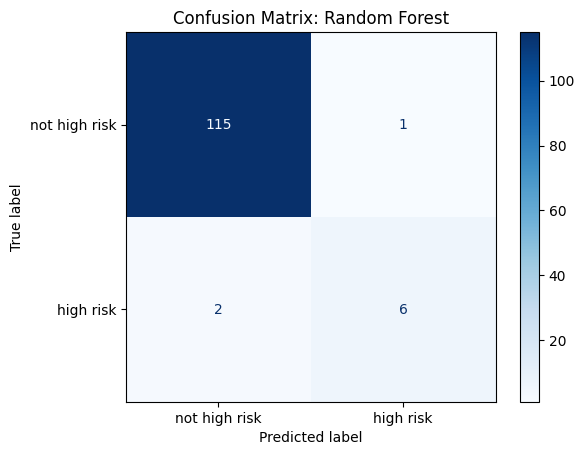

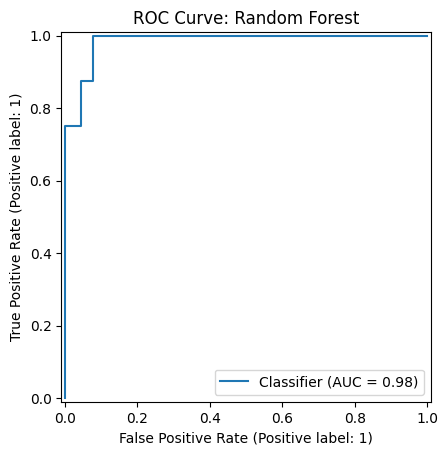

In [8]:
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else y_pred

print("Best model:", best_model_name)
print(classification_report(y_test, y_pred, target_names=["not high risk", "high risk"], zero_division=0))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["not high risk", "high risk"],
).plot(cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

if len(set(y_test)) > 1:
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"ROC Curve: {best_model_name}")
    plt.show()

## 7. Feature Importance

Feature importance helps explain what the model is using to classify next-year malaria risk.

,feature,importance
7,cases_per_100k_lag1,0.194863
11,cases_rate_roll3,0.187820
12,cases_rate_roll5,0.183121
8,cases_per_100k_lag2,0.136398
9,cases_per_100k_lag3,0.083945
10,deaths_per_100k_lag1,0.060010
1,population_2011,0.032600
0,year,0.017178
6,total_deaths_lag1,0.017133
14,rate_yoy_change,0.016183


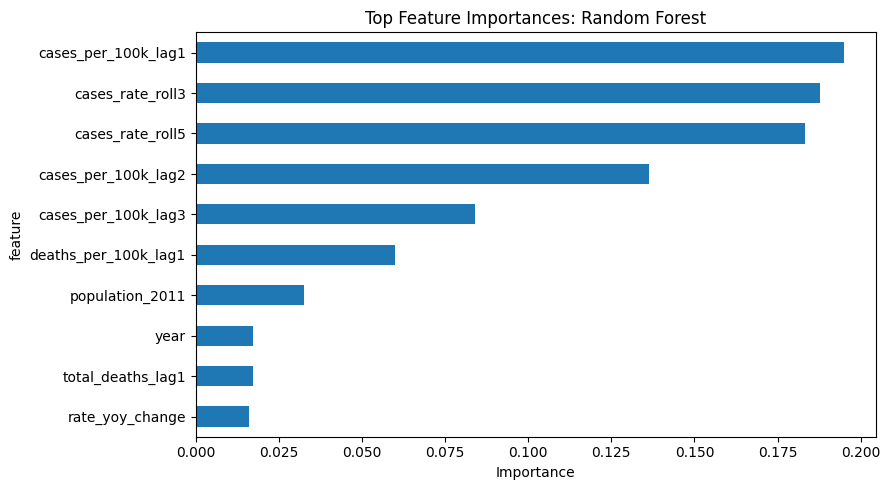

In [9]:
if best_model_name in ["Random Forest", "Gradient Boosting"]:
    importance_values = best_model.feature_importances_
elif best_model_name == "Logistic Regression":
    importance_values = np.abs(best_model.named_steps["model"].coef_[0])
else:
    importance_values = np.zeros(len(feature_cols))

importance_df = (
    pd.DataFrame({"feature": feature_cols, "importance": importance_values})
    .sort_values("importance", ascending=False)
)

display(importance_df)

importance_df.head(10).sort_values("importance").plot(
    x="feature", y="importance", kind="barh", figsize=(9, 5), legend=False
)
plt.title(f"Top Feature Importances: {best_model_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 8. Predictions for Selected Regions

This table focuses on Odisha, Mizoram, and Tripura, matching the regions used in the geospatial and mechanistic notebook.

In [10]:
prediction_table = test.copy()
prediction_table["predicted_high_risk"] = y_pred
prediction_table["predicted_high_risk_probability"] = y_prob

selected_predictions = prediction_table[prediction_table["state"].isin(SELECTED_REGIONS)][
    [
        "state",
        "year",
        "cases_per_100k",
        "next_year_rate",
        "high_risk_next_year",
        "predicted_high_risk",
        "predicted_high_risk_probability",
    ]
].sort_values(["state", "year"])

display(selected_predictions)

,state,year,cases_per_100k,next_year_rate,high_risk_next_year,predicted_high_risk,predicted_high_risk_probability
710,Mizoram,2020,706.157276,679.635365,1,1,0.805833
742,Mizoram,2021,679.635365,1011.660527,1,1,0.798872
776,Mizoram,2022,1011.660527,1640.530584,1,1,0.831128
809,Mizoram,2023,1640.530584,392.633653,1,1,0.830750
712,Odisha,2020,95.020234,57.435257,0,0,0.372194
744,Odisha,2021,57.435257,53.818751,0,0,0.101198
778,Odisha,2022,53.818751,96.011318,0,0,0.063287
811,Odisha,2023,96.011318,20.827071,0,0,0.010691
720,Tripura,2020,92.408185,50.681602,0,0,0.394568
752,Tripura,2021,50.681602,347.612643,1,0,0.215175


## 9. Interpretation

Use the model outputs to answer:

- Which model performs best for high-risk classification?
- Are lagged case rates more important than raw counts?
- Do high-burden states like Odisha, Mizoram, and Tripura remain high-risk in the test period?
- Where does the model make mistakes?

### Biological Limitation

This AI/ML model does not include explicit biological mechanisms. It does not model mosquitoes, rainfall, temperature, immunity, treatment, or intervention coverage. It should be interpreted as a risk prediction model, not a full transmission model.